<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/MNA_IAyAA_Actividad_semana_arboles_2_partes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Maestría en Inteligencia Artificial Aplicada**

## **Curso: Inteligencia Artificial y Aprendizaje Automático**

Tecnológico de Monterrey

Prof Luis Eduardo Falcón Morales

### **Actividad de la semana: modelos basados en Árboles**


* **Nombre:** JOSEGREG DE JESUS TOVAR BLANCO

* **matrícula:** A01840476


Agrega tus comentarios y celdas de código donde se te indica.

# **PRIMERA PARTE : Métricas de Clasificación**

In [33]:
# Importamos lo necesario para la actividad:

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
from sklearn.dummy import DummyClassifier
from IPython.display import display
from xgboost import plot_tree
import matplotlib.pyplot as plt


np.random.seed(17)

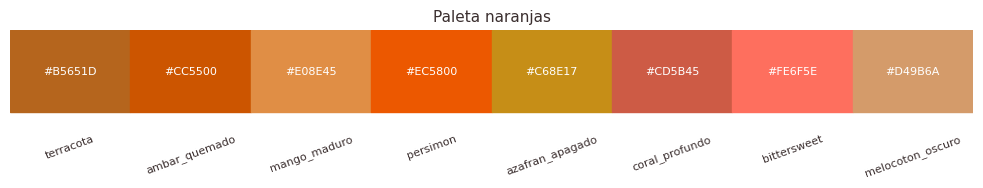

In [34]:

# Paleta de colores: tonos naranjas no convencionales para visualizaciones de toda la actividad

from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Tonos naranjas alejados del "naranja Halloween" típico:
# terracota, ámbar quemado, mango maduro, persimón, azafrán apagado,
# coral profundo, bittersweet, melocotón oscuro
paleta_naranjas = {
    'terracota':       '#B5651D',
    'ambar_quemado':   '#CC5500',
    'mango_maduro':    '#E08E45',
    'persimon':        '#EC5800',
    'azafran_apagado': '#C68E17',
    'coral_profundo':  '#CD5B45',
    'bittersweet':     '#FE6F5E',
    'melocoton_oscuro':'#D49B6A',
}

# Visualizamos la paleta para tenerla a la mano:
fig, ax = plt.subplots(figsize=(10, 2))
for i, (nombre, hex_color) in enumerate(paleta_naranjas.items()):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=hex_color))
    ax.text(i + 0.5, -0.25, nombre, ha='center', va='top', fontsize=8, rotation=20)
    ax.text(i + 0.5, 0.5, hex_color, ha='center', va='center', fontsize=8, color='white')
ax.set_xlim(0, len(paleta_naranjas))
ax.set_ylim(-0.6, 1)
ax.axis('off')
ax.set_title("Paleta naranjas", fontsize=11)
plt.tight_layout()
display(fig)
plt.close(fig)



In [35]:
# Para esta primera parte vamos a generar datos sintéticos para un problema de
# clasificación binario utilizando "make_classification" de scikitlearn.
# Esta función es muy útil para generar datos sintéticos y usada mucho en la
# comunidad de aprendizaje automático para generar y aprender los diversos
# modelos de aprendizaje automático. Por lo que es importante que te
# familiarices con ella y algunos de sus argumentos como mostramos a continuación.

# Recuerda consultar la documentación para mayor información:
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html


# Utilizaremos los siguientes valores de los hiperparámetros de make_classification:
# - n_samples: número de muestras o registros a generar.
# - n_features: número total de características o variables de entrada X. Incluye informativas, redundantes, duplicadas.
# - n_informative: número de características informativas o independientes.
# - n_redundant: número de características redundantes.
# - weights: pesos para las clases [0,1]-->[Clase_Mayoritaria_Negativa(0), clase_minoritaria_positiva(1)].
# - class_sep: separación entre clases ( <1 más entrelazados y más complejo el problema. >1, más separados y más fácil de resolver).
# - n_classes: número de clases.
# - n_clusters_per_class: número de cúmulos por clase. Mayor a 1, más complejo.
# - flip_y: fracción de registros cuya etiqueta se cambia de manera errónea y aleatoria (ruido) para hacer más complejo el problema.
# - random_state: semilla para reproducibilidad.

X, y = make_classification(
    n_samples=10_000,          # 10,000 registros
    n_features=20,             # factores en total
    n_informative=15,          # factores informativos o variables de entrada independientes
    n_redundant=5,             # factores redundantes (dependientes). Para añadir complejidad usamos valor > 0
    weights=[0.88, 0.12],      # Desbalance de clases: Mayoritaria clase 0; minoritaria clase 1
    class_sep=1.0,             # Separación entre clases. Más grande, más separadas y problemas más sencillos.
    n_classes=2,               # Dos clases para nuestro ejercicio.
    n_clusters_per_class=1,    # Para agregar complejidad adicional considera valores > 1
    flip_y=0.01,               # Añadir algo de ruido. default 0.01
    random_state=17,           # Semilla para la repetibilidad
)

In [36]:
# Defimos los datos como un DataFrame de Pandas para su mejor manejo:
feature_names = [f'feature_{i+1}' for i in range(20)]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Total de registros generados: {len(df)}")
print(f"Distribución de clases: {df['target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'}")
print(f"Cantidad de factores: {len(feature_names)}")

Total de registros generados: 10000
Distribución de clases: target
0    87.7%
1    12.3%
Name: proportion, dtype: object
Cantidad de factores: 20


In [37]:
pd.DataFrame(df).describe().T

,count,mean,std,min,25%,50%,75%,max
feature_1,10000.0,1.016138,2.243319,-6.429702,-0.520059,1.025274,2.535350,9.286981
feature_2,10000.0,0.785670,1.994150,-8.578184,-0.462409,0.851269,2.137617,7.937184
feature_3,10000.0,-0.757783,2.127136,-9.574402,-2.200615,-0.782594,0.630210,9.676054
feature_4,10000.0,1.733561,4.820216,-19.158886,-1.578108,1.751568,5.036626,19.051885
feature_5,10000.0,1.004263,2.309019,-6.665816,-0.540579,0.990261,2.538778,9.991830
feature_6,10000.0,-0.758315,2.682632,-11.246005,-2.561001,-0.780123,1.025289,10.297298
feature_7,10000.0,-0.448463,5.527866,-24.457356,-4.152116,-0.447135,3.285445,21.695749
feature_8,10000.0,0.974038,2.446141,-7.820102,-0.651334,0.977687,2.634129,11.292973
feature_9,10000.0,-0.769954,2.546797,-11.410437,-2.475215,-0.740625,0.947244,7.435675
feature_10,10000.0,0.739749,2.267579,-7.860020,-0.747975,0.768796,2.290440,9.363365


In [38]:
# Separamos las variables de entrada y la variable objetivo de salida:
X = df.drop('target', axis=1).values
y = df['target'].values

# Para los fines de este ejercicios solo dividimos el conjunto de datos
# en entrenamiento (80%) y validación (20%).
# Además usamos "stratify" para mantener la proporción de clases en la partición.
Xtrain, Xvalidation, ytrain, yvalidation = train_test_split(X, y, train_size=0.8, random_state=17, stratify=y)

print(f"Tamaño del conjunto de entrenamiento: {Xtrain.shape[0]} muestras")
print(f"Tamaño del conjunto de validación: {Xvalidation.shape[0]} muestras")

Tamaño del conjunto de entrenamiento: 8000 muestras
Tamaño del conjunto de validación: 2000 muestras


**Recuerda revisar la documentación de la función Dummy:**

https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html

In [39]:
# Obtengamos los siguientes resultados con la función Dummy:

estrategias = ['most_frequent','prior','stratified','uniform', "constant"]

print("Salidas del modelo Dummy con sus diferentes estrategias para")
print("buscar los diferentes umbrales del modelo base (baseline)")
print("según la métrica de referencia:")
print("-"*60)
print("\n")

for estrategia in estrategias:
  dummy_clf = DummyClassifier(strategy=estrategia,
                              random_state=17,
                              constant=1
                              )
  dummy_clf.fit(Xtrain, ytrain)
  y_pred = dummy_clf.predict(Xvalidation)

  # Lista para almacenar resultados
  results = []

  # "pos_label" indica la clase con respecto a la cual evaluar cada métrica.
  # Esto es útil en caso de que la clase de interés tenga un valor particular.
  acc = accuracy_score(yvalidation, y_pred)
  rec = recall_score(yvalidation, y_pred, pos_label=1)
  prec = precision_score(yvalidation, y_pred, pos_label=1)
  f1_sc = f1_score(yvalidation, y_pred, pos_label=1)

  results.append({'Accuracy': acc,
                'Recall': rec,
                'Precision': prec,
                'F1 Score': f1_sc
                })

  print(f"Estrategia: {estrategia}")
  print(f"Accuracy: {acc:.4f}")
  print(f"Recall: {rec:.4f}")
  print(f"Precision: {prec:.4f}")
  print(f"F1 Score: {f1_sc:.4f}")

  print("Matriz de Confusión:")
  cm = confusion_matrix(yvalidation, y_pred)
  print(cm)
  print("-"*30)
  print("\n")


Salidas del modelo Dummy con sus diferentes estrategias para
buscar los diferentes umbrales del modelo base (baseline)
según la métrica de referencia:
------------------------------------------------------------


Estrategia: most_frequent
Accuracy: 0.8770
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1754    0]
 [ 246    0]]
------------------------------


Estrategia: prior
Accuracy: 0.8770
Recall: 0.0000
Precision: 0.0000
F1 Score: 0.0000
Matriz de Confusión:
[[1754    0]
 [ 246    0]]
------------------------------


Estrategia: stratified
Accuracy: 0.8060
Recall: 0.1341
Precision: 0.1587
F1 Score: 0.1454
Matriz de Confusión:
[[1579  175]
 [ 213   33]]
------------------------------


Estrategia: uniform
Accuracy: 0.4820
Recall: 0.4472
Precision: 0.1089
F1 Score: 0.1752
Matriz de Confusión:
[[854 900]
 [136 110]]
------------------------------


Estrategia: constant
Accuracy: 0.1230
Recall: 1.0000
Precision: 0.1230
F1 Score: 0.2191
Matriz de Confusión:
[[

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Ejercicio - 1**


**En la salida anterior se obtuvieron dos advertencias (warnings).**

* **1a) Explica en qué consisten cada una de estas 5 estrategias. En particular, ¿cuál es la diferencia entre "prior" y "most frequent"?**

* **1b) ¿A cuáles casos de las estrategias Dummy están asociadas esas advertencias?**

* **1c) Explica qué significan esas advertencias y relaciona la explicación con los valores de las matrices de confusión correspondientes.**

* **1d) Suponiendo que vamos a utilizar estos datos para entrenar un modelo basado en árboles, ¿cuál es la recomendación en relación a si debemos o no escalar los datos numéricos de entrada?**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **1a)**

El DummyClassifier de scikit-learn es un baseline que genera predicciones siguiendo reglas simples sin aprender patrones de los datos. Las cinco estrategias disponibles son:

**most_frequent:** predice siempre la clase más frecuente del conjunto de entrenamiento.

**prior:** se comporta idéntico a most_frequent ya que predice siempre la clase más frecuente, pero en predict_proba() devuelve la distribución real del entrenamiento por ejemplo, [0.88, 0.12] en nuestro caso.

**stratified:** genera predicciones aleatorias ponderadas por la distribución de clases del entrenamiento. Equivale a lanzar un dado cargado con las proporciones reales (88% clase 0, 12% clase 1).

**uniform:** genera predicciones aleatorias uniformes entre todas las clases, ignorando el desbalance real. Equivale a una moneda justa (50/50 en problema binario).

**constant:** predice siempre una clase fija indicada por el usuario mediante el parámetro constant=. En esta actividad se usó constant=1, por lo que siempre predice la clase minoritaria.

**Diferencia entre prior y most_frequent:** ambas estrategias producen exactamente las mismas predicciones de clase al llamar a predict(), y por lo tanto generan matrices de confusión idénticas y los mismos valores de Accuracy, Precision, Recall y F1-Score. La diferencia es en predict_proba(): most_frequent devuelve probabilidades binarias (1.0 / 0.0), mientras que prior devuelve la distribución a priori real del entrenamiento.

* **1b)** None

Las dos advertencias están asociadas a las estrategias most_frequent y prior. Ambas estrategias predicen siempre la clase mayoritaria (clase 0), por lo que nunca generan predicciones de la clase positiva (clase 1).

* **1c)** None

Las advertencias son porque las métricas Precision y F1-Score están "mal definidas" porque su cálculo involucra una división entre cero. al revisar las matrices de confusión de most_frequent y prior, vemos que la columna de predicciones positivas (Pred=1) está completamente en cero (TP=0TP = 0
TP=0 y FP=0FP = 0 FP=0), generando la indeterminación, y por compatibilidad numérica, sklearn asigna el valor 0.0 a estas métricas y emite la advertencia.

* **1d)** None

Para modelos basados en árboles no es necesario escalar los datos numéricos de entrada. Estos modelos son invariantes ante transformaciones de las variables, porque las decisiones se basan en encontrar umbrales óptimos sobre cada variable de manera independiente, evaluando la ganancia de información en cada partición. El orden relativo de los datos se preserva al escalar, por lo que la estructura del árbol resultante y sus predicciones son idénticas con o sin escalado, seria como añadir un paso innecesario.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

## **Ejercicio - 2**

**Sabemos que tenemos un problema de clases desbalanceadas y debiéramos utilizar otra métrica que nos ayude a medir mejor el desempeño del modelo. En particular, nos interesaría saber cuándo el modelo está subentrenado con respecto a una métrica en particular.**

**Para ello, indica cuál sería el valor del modelo base (baseline) que debiéramos utilizar, si utilizáramos como métrica la que se indica en cada inciso:**


++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

Tomando un modelo base: most frequent

* **2a) Accuracy:** 0.88  el modelo Dummy most_frequent acierta el 88% por el desbalance.

* **2b) Precision:** 0.00 (indefinido por división 0/00/0
0/0) — al no predecir ninguna clase positiva, la métrica no es computable y sklearn la asigna como 0.

* **2c) Recall:** 0.00 — no atrapa ningún positivo real.

* **2d) F1-Score:** 0.00 (indefinido) — al ser el promedio armónico de Precision y Recall, hereda la indeterminación.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **SEGUNDA PARTE : XGBoost**

### **En el siguiente ejercicio explorarás el efecto de algunos de los argumentos del modelo XGBoost.**

 Puedes consultar la documentación:

https://xgboost.readthedocs.io/en/latest/python/python_api.html

Usaremos la base de datos llamada breast-cancer-Wisconsin:

https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-dataset

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html



## **Ejercicio - 3**

### **Describe en qué consiste la base de datos breast_cancer.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++


El dataset Breast Cancer Wisconsin contiene 569 muestras de biopsias mamarias obtenidas por aspiración con aguja fina (FNA) y digitalizadas como imágenes. Cada muestra está descrita por 30 variables numéricas continuas que caracterizan los núcleos celulares de la imagen.
Las 30 features se construyen a partir de 10 características base (radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal), cada una reportada con 3 estadísticos: media (mean), error estándar (standard error) y peor caso (worst).
La variable objetivo es binaria: 0 = Maligno (212 casos, aprox un 37%) y 1 = Benigno (357 casos, aprox un 63%).

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

In [40]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb
from xgboost import plot_importance, plot_tree

In [41]:
# Cargamos el dataset de ejemplo:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


In [42]:
pd.DataFrame(X).describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## **Ejercicio - 4**

**De la documentación, sabemos que las etiquetas están dadas como sigue:**

* **Malignant (0)**

* **Benign (1)**

* **Distribución de clases: 212 malignos, 357 benignos.**

**Describe 3 razones a favor y 3 en contra para dejar las etiquetas como fueron registradas en esta base de datos.**

**4a) Razones a favor de dejar las etiquetas como están:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **4a.1) Evitas modificaciones innesarias sobre los datos, esto favorece la trazabilidad y reproducibilidad del analisis **

* **4a.2) vamos a trabajar con modelo de arboles y la capacidad predictiva del modelo no cambia por el simple intercambio de etiquetas.**

* **4a.3) Las métricas globales (Accuracy, ROC-AUC) no se ven afectadas, si solo necesitamos evaluar el desempeño general del modelo, mantener las etiquetas originales no introduce ningún sesgo de evaluación.**

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**4b) Razones en contra de dejar las etiquetas como están, es decir, a favor de intercambiarlas:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

* **4b.1) Focalización de la clase positiva o clase de interés. En la práctica de ML, la clase minoritaria y crítica (Maligno) debería ser la positiva (1). Esto alinea las métricas Precision, Recall y F1 directamente con lo que importa: detectar correctamente los casos malignos.**

* **4b.2) Derivada de la anterior: interpretación correcta de los Falsos Negativos. En un problema médico, un Falso Negativo es el peor error: decirle a un paciente que está sano cuando tiene cáncer. Con la convención correcta (Maligno=1), un FN significa exactamente eso. Con las etiquetas invertidas, el "FN" del modelo correspondería a decirle a un paciente sano que tiene cáncer, lo cual confunde la lectura de la matriz de confusión y puede llevar a decisiones operativas erróneas**

* **4b.3) Compatibilidad con el argumento pos_label=1 de sklearn. Las funciones precision_score, recall_score y f1_score usan por defecto pos_label=1. Si dejamos Benigno=1, todas las métricas se calculan sobre la clase benigna a menos que pasemos explícitamente pos_label=0 en cada llamada.**

+++++++++++++ Termina sección de tus comentarios

In [43]:
# 4c) En esta Actividad optaremos por intercambiar las etiquetas.
#     Intercambia a continuación las etiquetas de la variable de salida.
#     Llamar "y_swap" a la nueva variable.

#########################################################################
# INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.


# Operación de intercambio: 0 a 1 se logra con (1 - y)
y_swap = 1 - y

# Comprobación visual:
distribuciones = {
    'Distribución original (Maligno=0, Benigno=1)': {
        'Maligno (0)': int(np.sum(y == 0)),
        'Benigno (1)': int(np.sum(y == 1))
    },
    'Distribución intercambiada (Maligno=1, Benigno=0)': {
        'Benigno (0)': int(np.sum(y_swap == 0)),
        'Maligno (1)': int(np.sum(y_swap == 1))
    }
}

display(distribuciones)


# TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
#########################################################################

# Desplegemos y verifiquemos la nueva distribución:
print(f"Distribución original: 0={np.sum(y==0)}, 1={np.sum(y==1)}")
print(f"Distribución con el intercambio: 0={np.sum(y_swap==0)}, 1={np.sum(y_swap==1)}")

{'Distribución original (Maligno=0, Benigno=1)': {'Maligno (0)': 212,
  'Benigno (1)': 357},
 'Distribución intercambiada (Maligno=1, Benigno=0)': {'Benigno (0)': 357,
  'Maligno (1)': 212}}

Distribución original: 0=212, 1=357
Distribución con el intercambio: 0=357, 1=212


In [44]:
# Dividimos en conjuntos de entrenamiento y prueba
# para los própósitos de nuestro ejercicio:

X_train, X_validation, y_train, y_validation = train_test_split(X, y_swap,
                                                                train_size=0.8,
                                                                random_state=7,
                                                                stratify=y
                                                                )

In [45]:
print("Información del conjunto de entrenamiento (train):")
print("*"*50)
print(f"Número de características: {X_train.shape[1]}")
print(f"Número de muestras: {X_train.shape[0]}")
print(f"Distribución de clases [Benigno(0), Maligno(1)]-->{np.bincount(y_train)}-->{np.bincount(y_train)/y_train.shape[0]}")


Información del conjunto de entrenamiento (train):
**************************************************
Número de características: 30
Número de muestras: 455
Distribución de clases [Benigno(0), Maligno(1)]-->[285 170]-->[0.62637363 0.37362637]


In [46]:
print("\nAnálisis descriptivo:")
print(X_train.describe().T)


Análisis descriptivo:
                         count        mean         std         min  \
mean radius              455.0   14.033989    3.418139    6.981000   
mean texture             455.0   19.330593    4.375076    9.710000   
mean perimeter           455.0   91.328484   23.485102   43.790000   
mean area                455.0  644.779560  335.949232  143.500000   
mean smoothness          455.0    0.096469    0.013941    0.062510   
mean compactness         455.0    0.104115    0.050855    0.019380   
mean concavity           455.0    0.086458    0.073521    0.000000   
mean concave points      455.0    0.048380    0.037189    0.000000   
mean symmetry            455.0    0.180572    0.026421    0.106000   
mean fractal dimension   455.0    0.062925    0.007066    0.049960   
radius error             455.0    0.395571    0.251801    0.111500   
texture error            455.0    1.208644    0.533237    0.360200   
perimeter error          455.0    2.801167    1.794209    0.757000 

In [47]:
# Definimos nuestro modelo XGBoost básico:
mis_estimadores=100
mi_modelo_xgb = xgb.XGBClassifier(objective='binary:logistic',  # Para clasificación binaria.
                                  n_estimators= mis_estimadores,
                                  learning_rate= 1.0,
                                  random_state=17
                                  )

# Aquí generamos el modelo XGBoost de nuestro ejercicio:
mi_modelo_xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1.0, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

## **Ejercicio - 5**


ÁRBOL 0


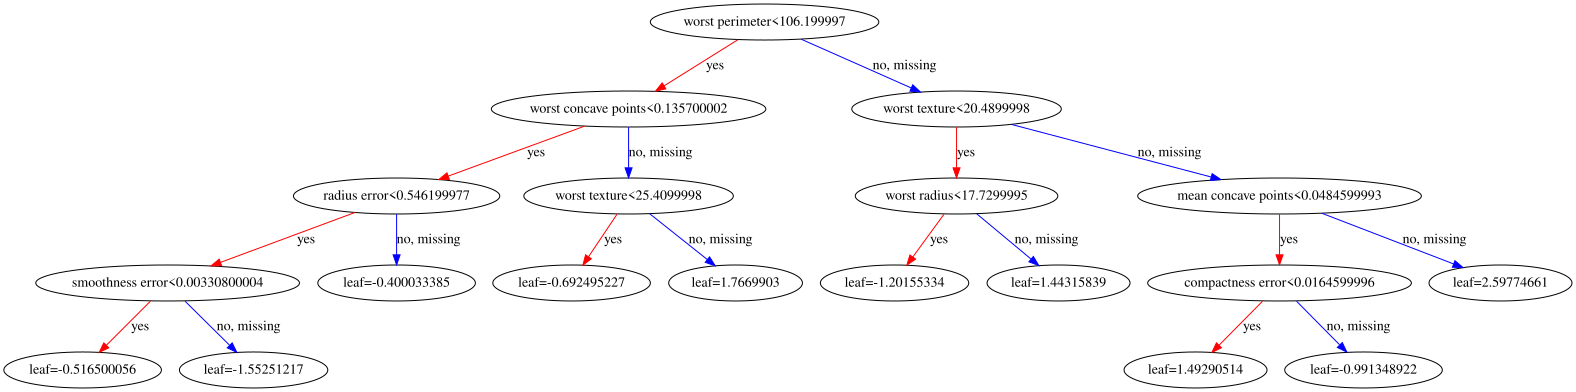


ÁRBOL 9


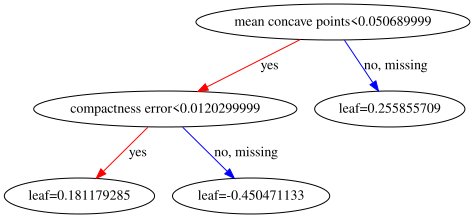


ÁRBOL 30


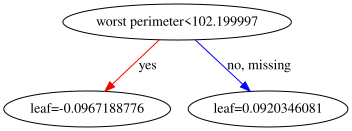


ÁRBOL 38


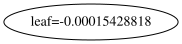


ÁRBOL 99


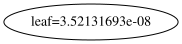

In [48]:
# 5a) Con base al modelo XGBoost generado previamente, con 100 estimadores
#     y los valores inidcados en la celda anterior, despliega los árboles
#     con índices 0, 9, 30, 38 y 99.
#
#     Puedes consultar la documentación:
#     https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.plotting
#     https://xgboosting.com/how-to-use-xgboost.plot_tree/


#########################################################################
# INICIA LA SECCIÓN PARA AGREGAR CÓDIGO.
# Agrega todas las líneas o celdas de código que consideres necesarias.


from xgboost import to_graphviz

arboles_a_visualizar = [0, 9, 30, 38, 99]

for indice_arbol in arboles_a_visualizar:

    print(f"\n{'='*70}")
    print(f"ÁRBOL {indice_arbol}")
    print(f"{'='*70}")

    grafico = to_graphviz(
        mi_modelo_xgb,
        tree_idx=indice_arbol,
        rankdir='TB'
    )

    display(grafico)

# TERMINA LA SECCIÓN PARA AGREGAR CÓDIGO.
#########################################################################


**5b) Con base a los 5 diagramas de árbol obtenidos en el inciso anterior y a la manera en que funciona el modelo XGBoost, explica el comportamiento de dichos árboles en relación a su profundidad.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

En XGBoost los árboles se entrenan secuencialmente sobre los residuos del modelo acumulado. El árbol 0 enfrenta el problema desde cero y necesita usar la profundidad máxima permitida (max_depth=6 por defecto). Los árboles posteriores capturan patrones residuales cada vez más pequeñitos y sutiles, por lo que su profundidad va disminuyendo progresivamente. A partir de cierto estimador, los residuos son tan pequeñitos que XGBoost no encuentra particiones con ganancia suficiente y genera árboles de un solo nodo (raíz). Esto confirma que el modelo converge antes de completar los 100 estimadores configurados.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**5c) En particular, explica el grafo obtenido con tree_idx=9, con respecto a los nombres de los factores que aparecen en cada uno de sus nodos y delas clases de salida Benigno-Maligno.**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

El árbol con índice 9 tiene una profundidad efectiva de 2 niveles y utiliza dos features del dataset: mean concave points (en la raíz, con umbral 0.0507) y compactness error (en el nodo intermedio, con umbral 0.0120). Es un árbol pequeño porque, al ser el décimo del ensemble, los árboles anteriores ya capturaron los patrones más importantes y este solo afina residuos.
Tiene 3 hojas con valores logarítmicos que se interpretan así (recordando que tras el swap del Ejercicio 4, Maligno=1 y Benigno=0):

**Hoja derecha (+0.2559):** cuando mean concave points ≥ 0.0507, el árbol empuja la predicción hacia Maligno. Tiene sentido clínico: un alto número de puntos cóncavos en los núcleos celulares es característico de células malignas.

**Hoja izquierda-derecha (−0.4505):** cuando los puntos cóncavos son bajos pero el compactness error es alto (≥ 0.0120), el árbol empuja fuertemente hacia Benigno. Es la hoja con mayor magnitud, lo que indica que esta combinación es la más discriminante para este.

**Hoja izquierda-izquierda (+0.1812):** cuando ambas condiciones de "anormalidad" son bajas, el árbol aún empuja levemente hacia Maligno. Esto sugiere un patrón residual sutil que los 9 árboles anteriores no habían capturado.


+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**5d) ¿Cómo interpretas lo gráficos 38 y 99?**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

Los árboles con índices 38 y 99 muestran una estructura extremadamente simple, compuesta únicamente por una hoja terminal. Sus valores de salida son muy cercanos a cero (-0.000154 y 0.000000035 respectivamente), lo que indica que el modelo ya había capturado la mayor parte de la información relevante en árboles anteriores. A diferencia de los primeros árboles, que realizan particiones utilizando variables predictoras importantes, estos árboles tardíos únicamente realizan ajustes marginales sobre los errores residuales. Esto sugiere que el algoritmo se encuentra cercano a la convergencia y que las correcciones adicionales aportan mejoras prácticamente insignificantes al desempeño global del modelo.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

**5e) De hecho, puedes verificar que para este ejemplo los árboles obtenidos desde el índice 38 al 99, todos son de un solo nodo. ¿Qué recomendaciones o ajustes podrías proponer en el entrenamiento del modelo tomando en cuenta esta observación?**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++

Ya todos los árboles generados desde el índice 38 hasta el 99 contienen únicamente una hoja terminal, puede concluirse que el modelo dejó de encontrar particiones capaces de mejorar significativamente la función objetivo. Esto sugiere que la mayor parte del aprendizaje se completó antes del árbol 38 y que los árboles posteriores únicamente realizan correcciones marginales. Como primera recomendación, sería conveniente reducir el parámetro n_estimators a un valor cercano a 40 para disminuir el costo computacional sin afectar significativamente el desempeño. Adicionalmente, se recomienda implementar early_stopping_rounds para que el algoritmo determine automáticamente cuándo detener el entrenamiento. Finalmente, podrían explorarse ajustes en parámetros como learning_rate, gamma o min_child_weight para verificar si existe potencial de mejora adicional en la capacidad de generalización del modelo.

+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

## **Ejercicio - 6**

**Incluye tus comentarios finales de esta actividad:**

++++++++++++++ Inicia sección de tus comentarios ++++++++++++++++++


Esta actividad me permitió comprender de forma práctica cómo funcionan los **modelos basados en árboles** y cómo los conceptos teóricos de entropía, ganancia de información y boosting se reflejan directamente en la construcción de los modelos.

En primer lugar, el uso de un modelo baseline mediante **DummyClassifier** mostró la importancia de contar con una referencia mínima de desempeño. En problemas con clases desbalanceadas, una alta exactitud no necesariamente implica que el modelo esté aprendiendo patrones útiles, por lo que resulta indispensable compararlo contra un modelo base antes de evaluar su utilidad real.

Respecto a las métricas, se comprobó al igual que en el ejercicio anterior que Accuracy puede ser engañosa cuando una clase domina al conjunto de datos. Métricas como Precision, Recall y F1-Score permiten evaluar con mayor detalle la capacidad del modelo para identificar correctamente la clase de interés, especialmente cuando el costo de cometer errores no es simétrico.

También se observó que los modelos basados en árboles no requieren escalamiento de variables (esta parte del pre procesamiento me parecio interesante), ya que realizan sus divisiones utilizando umbrales sobre los valores originales. Esto simplifica el proceso de preprocesamiento y mantiene la interpretabilidad de los resultados.

La visualización de los árboles de XGBoost permitió entender que el algoritmo construye un conjunto de árboles secuenciales donde cada nuevo árbol corrige errores residuales de los anteriores. Los primeros árboles aportan la mayor parte del aprendizaje, mientras que los últimos realizan ajustes cada vez más pequeños. El hecho de que los árboles del índice 38 al 99 estuvieran formados por un solo nodo indica que el modelo había convergido y que existía poca información adicional por aprender.

Finalmente, esta observación permitió identificar oportunidades de mejora en el ajuste de hiperparámetros. Reducir el número de estimadores, disminuir el **learning_rate** e implementar **Early Stopping** podrían generar modelos más eficientes y con mejor capacidad de generalización.

En conclusión, la actividad mostró que el éxito de un modelo no depende unicamente del algoritmo utilizado, sino tambien de la selección adecuada de métricas, la correcta interpretación de los resultados y el ajuste informado de los hiperparámetros para lograr un equilibrio entre desempeño, complejidad y capacidad de generalización.


+++++++++++++ Termina sección de tus comentarios +++++++++++++++++++

# **<<Fin de la Actividad de la Semana : modelos basados en árboles>>**